# Lab 13: Exploring Data and Insights Using Multiple Linear Regression

## Introduction

This lab uses a public automobile dataset to explore the factors associated with vehicle fuel efficiency. Multiple linear regression will be used to evaluate how several vehicle characteristics collectively explain variation in miles per gallon (`mpg`).

The analysis will include data loading, cleaning, exploratory data analysis, regression modeling, statistical interpretation, and diagnostic visualizations. AI assistance will be documented throughout the notebook to support dataset selection, research-question development, interpretation of results, and visualization recommendations.

## Dataset

The Auto MPG dataset contains information about vehicle fuel efficiency and automobile characteristics. The target variable for this analysis is `mpg`, while potential predictors include vehicle weight, horsepower, displacement, acceleration, cylinders, and model year.

## Analysis Objectives

1. Load and examine the Auto MPG dataset.
2. Identify and handle missing values and potential outliers.
3. Define a meaningful research question involving multiple predictors.
4. Build a multiple linear regression model.
5. Evaluate coefficients, R², adjusted R², and p-values.
6. Create visualizations to assess relationships and model assumptions.
7. Summarize the findings, limitations, and role of AI in the workflow.

## Step 4: Import Libraries and Configure Project Paths

In this step, the required Python libraries are imported for data handling, statistical modeling, and visualization. Project folder paths are also defined so that datasets, charts, and report files can be stored in the appropriate directories.

In [3]:

# Import libraries for file and folder management
from pathlib import Path

# Import libraries for data analysis
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import statsmodels for multiple linear regression
import statsmodels.api as sm

# Configure Pandas display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Apply a consistent visualization style
sns.set_theme(style="whitegrid")

# Identify the current working directory
current_directory = Path.cwd()

# Identify the main project folder
# If the notebook is running from a project subfolder,
# move one level up to reach the project root
project_subfolders = {"notebooks", "data", "outputs", "reports"}

if current_directory.name.lower() in project_subfolders:
    project_root = current_directory.parent
else:
    project_root = current_directory

# Define paths for the project subfolders
data_directory = project_root / "data"
outputs_directory = project_root / "outputs"
reports_directory = project_root / "reports"

# Create the folders if they do not already exist
data_directory.mkdir(parents=True, exist_ok=True)
outputs_directory.mkdir(parents=True, exist_ok=True)
reports_directory.mkdir(parents=True, exist_ok=True)

# Display the configured folder locations
print(f"Current working directory: {current_directory}")
print(f"Project root: {project_root}")
print(f"Data directory: {data_directory}")
print(f"Outputs directory: {outputs_directory}")
print(f"Reports directory: {reports_directory}")


Current working directory: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\notebooks
Project root: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights
Data directory: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\data
Outputs directory: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs
Reports directory: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\reports


## Step 5: AI-Assisted Dataset Selection

### AI Tool Used

ChatGPT was used to help identify a suitable public dataset for multiple linear regression.

### Prompt Submitted to ChatGPT

> Recommend a publicly available dataset appropriate for a multiple linear regression analysis. The dataset should contain at least two predictor variables, one numeric target variable, enough observations for meaningful analysis, and variables that can support interpretation and visualization.

### AI Response and Recommendation

ChatGPT recommended the **Auto MPG dataset** from the UCI Machine Learning Repository. The dataset contains automobile characteristics and vehicle fuel-efficiency measurements. Its numeric target variable is `mpg`, representing miles per gallon.

Potential predictor variables include:

- `cylinders`
- `displacement`
- `horsepower`
- `weight`
- `acceleration`
- `model_year`
- `origin`

The dataset is appropriate for multiple linear regression because it contains one continuous target variable and several numeric predictors. It also provides opportunities to perform data cleaning, inspect missing horsepower values, evaluate correlations, identify possible outliers, and interpret the effects of vehicle characteristics on fuel efficiency.

### Dataset Selection Decision

The Auto MPG dataset was selected because it satisfies the assignment requirements and supports a meaningful investigation of how multiple automobile characteristics are associated with fuel efficiency.

### Dataset Source

Quinlan, R. (1993). *Auto MPG* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5859H

## Step 6: Load the Auto MPG Dataset

The Auto MPG dataset is loaded from the UCI Machine Learning Repository. A local copy is saved in the project data folder to support reproducibility and future use.

In [4]:
# Define the source URL for the Auto MPG dataset
dataset_url = (
    "https://archive.ics.uci.edu/ml/"
    "machine-learning-databases/auto-mpg/auto-mpg.data"
)

# Define the local file path
dataset_path = data_directory / "auto_mpg.csv"

# Define the dataset column names
column_names = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

# Load the dataset from the local file if it already exists
if dataset_path.exists():
    auto_mpg_df = pd.read_csv(dataset_path)
    print("Dataset loaded from the local data folder.")

# Otherwise, download the dataset and save a local copy
else:
    auto_mpg_df = pd.read_csv(
        dataset_url,
        sep=r"\s+",
        names=column_names,
        quotechar='"',
        na_values="?"
    )

    auto_mpg_df.to_csv(dataset_path, index=False)
    print("Dataset downloaded and saved to the local data folder.")

# Display the dataset dimensions
print(f"Number of rows: {auto_mpg_df.shape[0]}")
print(f"Number of columns: {auto_mpg_df.shape[1]}")
print(f"Saved dataset location: {dataset_path}")

Dataset downloaded and saved to the local data folder.
Number of rows: 398
Number of columns: 9
Saved dataset location: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\data\auto_mpg.csv


In [5]:
# Display the first 10 rows of the Auto MPG dataset
auto_mpg_df.head(10)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino
5,15.0,8,429.0,198.0,4341.0,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220.0,4354.0,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215.0,4312.0,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225.0,4425.0,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190.0,3850.0,8.5,70,1,amc ambassador dpl


## Step 8: Inspect Data Structure and Missing Values

The dataset structure, column data types, and missing values are examined to determine whether any variables require conversion or cleaning before the regression model is built.

In [6]:
# Display dataset structure and data types
print("Dataset Information:")
print("-" * 50)
auto_mpg_df.info()

# Count missing values in each column
print("\nMissing Values by Column:")
print("-" * 50)
missing_values = auto_mpg_df.isnull().sum()
print(missing_values)

# Display the total number of duplicate rows
duplicate_count = auto_mpg_df.duplicated().sum()

print("\nDuplicate Rows:")
print("-" * 50)
print(f"Number of duplicate rows: {duplicate_count}")

Dataset Information:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB

Missing Values by Column:
--------------------------------------------------
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

Duplicate Rows:
------------------

## Step 9: Examine Summary Statistics and Missing Records

Descriptive statistics are generated to understand the central tendency, variability, and range of the numeric variables. The records containing missing horsepower values are also examined before selecting an appropriate cleaning method.

In [7]:
# Display descriptive statistics for numeric variables
print("Descriptive Statistics:")
display(auto_mpg_df.describe().round(2))

# Display rows containing missing horsepower values
print("\nRows with Missing Horsepower Values:")
display(auto_mpg_df[auto_mpg_df["horsepower"].isnull()])

Descriptive Statistics:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.00,398.00,398.00,392.00,398.00,398.00,398.00,398.00
mean,23.51,5.45,193.43,104.47,2970.42,15.57,76.01,1.57
std,7.82,1.70,104.27,38.49,846.84,2.76,3.70,0.80
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00,1.00
25%,17.50,4.00,104.25,75.00,2223.75,13.82,73.00,1.00
50%,23.00,4.00,148.50,93.50,2803.50,15.50,76.00,1.00
75%,29.00,8.00,262.00,126.00,3608.00,17.18,79.00,2.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00,3.00



Rows with Missing Horsepower Values:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
32,25.0,4,98.0,NaN,2046.0,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875.0,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835.0,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905.0,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320.0,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035.0,20.5,82,1,amc concord dl


## Step 10: Clean Missing Values

Six observations contain missing horsepower values. Because these records represent only a small percentage of the dataset, they are removed rather than imputed. A separate cleaned DataFrame is created so that the original dataset remains unchanged.

In [8]:
# Create a separate copy of the original dataset
auto_mpg_clean_df = auto_mpg_df.copy()

# Record the number of rows before cleaning
rows_before_cleaning = auto_mpg_clean_df.shape[0]

# Remove rows with missing horsepower values
auto_mpg_clean_df = auto_mpg_clean_df.dropna(
    subset=["horsepower"]
).reset_index(drop=True)

# Record the number of rows after cleaning
rows_after_cleaning = auto_mpg_clean_df.shape[0]

# Calculate the number and percentage of removed rows
rows_removed = rows_before_cleaning - rows_after_cleaning
percentage_removed = (rows_removed / rows_before_cleaning) * 100

# Display the cleaning results
print(f"Rows before cleaning: {rows_before_cleaning}")
print(f"Rows after cleaning: {rows_after_cleaning}")
print(f"Rows removed: {rows_removed}")
print(f"Percentage of rows removed: {percentage_removed:.2f}%")
print(
    f"Remaining missing values: "
    f"{auto_mpg_clean_df.isnull().sum().sum()}"
)

Rows before cleaning: 398
Rows after cleaning: 392
Rows removed: 6
Percentage of rows removed: 1.51%
Remaining missing values: 0


## Step 11: AI-Assisted Research Question Development

### Prompt Submitted to ChatGPT

> Using the Auto MPG dataset, suggest a meaningful research question for multiple linear regression. The target variable should be miles per gallon (`mpg`), and the model should include several numeric vehicle characteristics as predictors. The research question should support clear statistical interpretation.

### AI Response and Recommendation

ChatGPT recommended investigating whether engine size, power, vehicle weight, acceleration, and manufacturing year collectively explain differences in vehicle fuel efficiency.

The following variables were recommended:

**Target variable**

- `mpg`: Vehicle fuel efficiency measured in miles per gallon

**Predictor variables**

- `cylinders`: Number of engine cylinders
- `displacement`: Engine displacement
- `horsepower`: Engine horsepower
- `weight`: Vehicle weight
- `acceleration`: Time required to accelerate
- `model_year`: Vehicle model year

### Final Research Question

> To what extent do the number of cylinders, engine displacement, horsepower, vehicle weight, acceleration, and model year collectively explain variation in vehicle fuel efficiency measured in miles per gallon?

This research question is appropriate for multiple linear regression because it examines the relationship between one continuous target variable and several numeric predictor variables.

## Step 12: Examine Potential Outliers

Boxplots and the interquartile range method are used to identify potential outliers in the target and predictor variables. Identified observations will be reviewed before deciding whether they represent data errors or valid automobile characteristics.

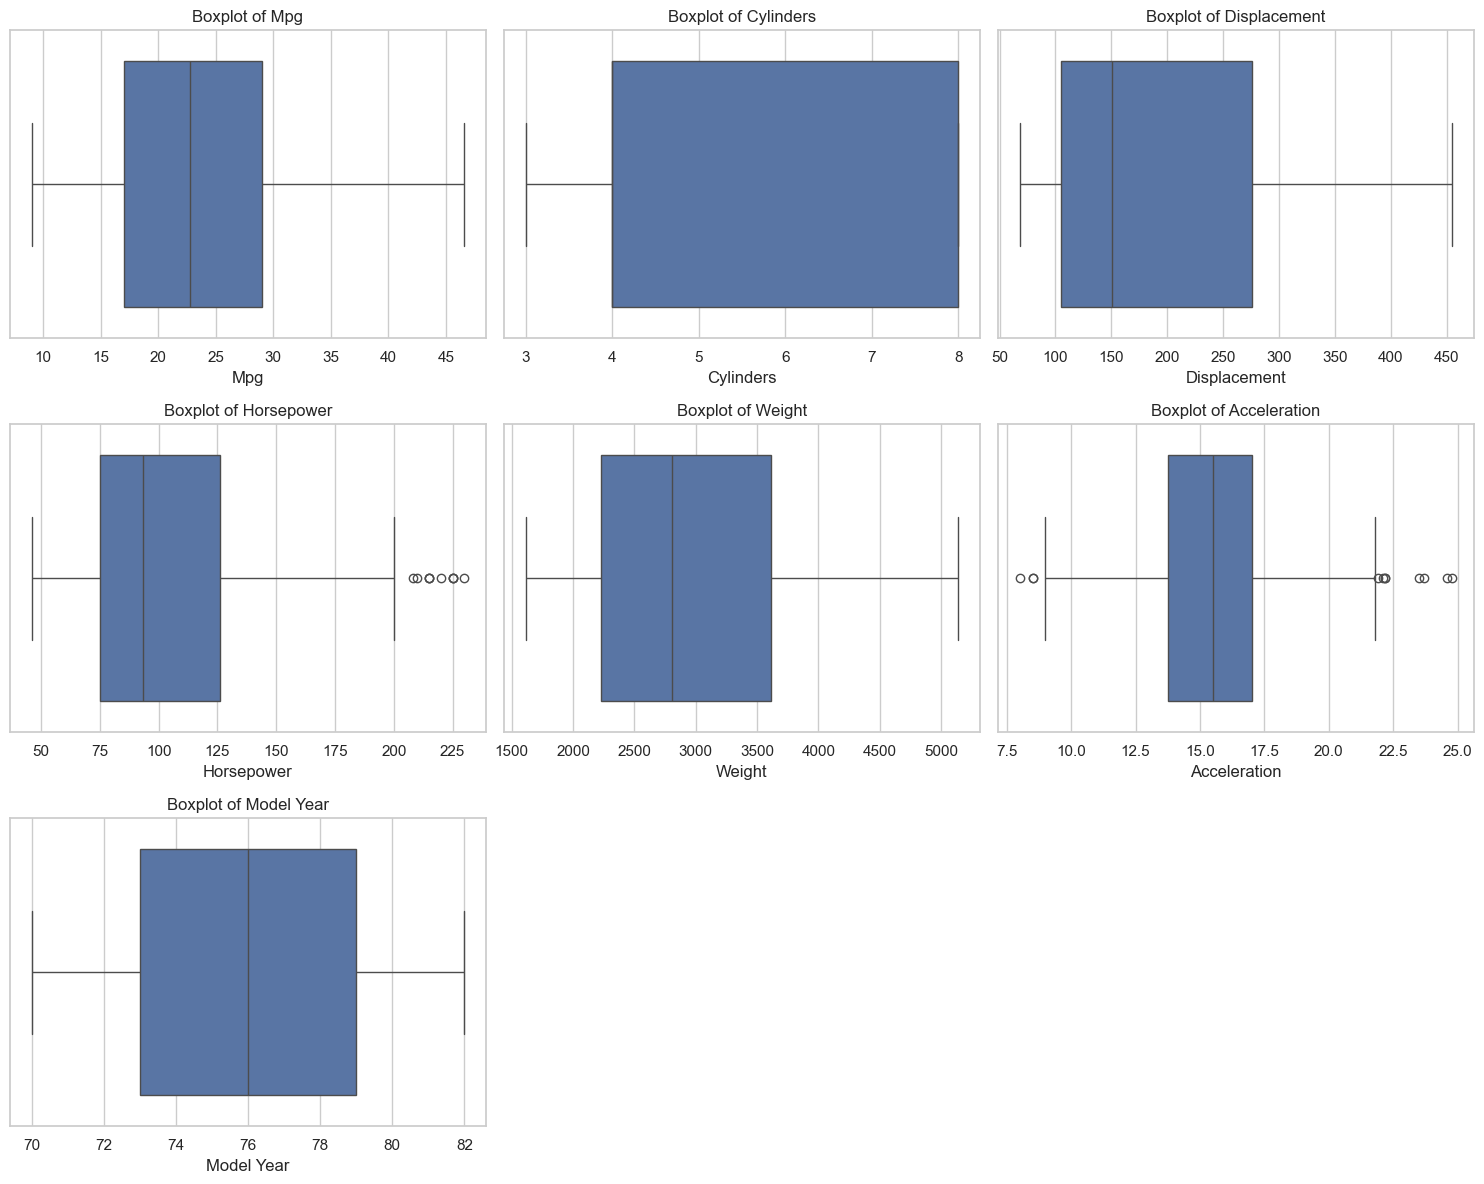

Boxplot saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs\02_model_variables_boxplots.png


In [9]:
# Define the variables that will be used in the regression analysis
model_variables = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]

# Create boxplots for the target and predictor variables
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for index, variable in enumerate(model_variables):
    sns.boxplot(
        x=auto_mpg_clean_df[variable],
        ax=axes[index]
    )

    axes[index].set_title(f"Boxplot of {variable.replace('_', ' ').title()}")
    axes[index].set_xlabel(variable.replace("_", " ").title())

# Hide any unused subplot areas
for index in range(len(model_variables), len(axes)):
    axes[index].set_visible(False)

plt.tight_layout()

# Save the boxplot figure
boxplot_path = outputs_directory / "02_model_variables_boxplots.png"
plt.savefig(boxplot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Boxplot saved to: {boxplot_path}")

In [10]:
# Create a dictionary to store IQR-based outlier counts
outlier_summary = {}

for variable in model_variables:
    first_quartile = auto_mpg_clean_df[variable].quantile(0.25)
    third_quartile = auto_mpg_clean_df[variable].quantile(0.75)
    interquartile_range = third_quartile - first_quartile

    lower_bound = first_quartile - (1.5 * interquartile_range)
    upper_bound = third_quartile + (1.5 * interquartile_range)

    outlier_count = auto_mpg_clean_df[
        (auto_mpg_clean_df[variable] < lower_bound)
        | (auto_mpg_clean_df[variable] > upper_bound)
    ].shape[0]

    outlier_summary[variable] = {
        "Lower_Bound": round(lower_bound, 2),
        "Upper_Bound": round(upper_bound, 2),
        "Potential_Outliers": outlier_count
    }

# Convert the outlier results into a DataFrame
outlier_summary_df = pd.DataFrame(outlier_summary).T

print("IQR-Based Potential Outlier Summary:")
display(outlier_summary_df)

IQR-Based Potential Outlier Summary:


,Lower_Bound,Upper_Bound,Potential_Outliers
mpg,-1.00,47.00,0.0
cylinders,-2.00,14.00,0.0
displacement,-151.12,531.88,0.0
horsepower,-1.50,202.50,10.0
weight,141.00,5699.00,0.0
acceleration,8.90,21.90,11.0
model_year,64.00,88.00,0.0


In [11]:
# Calculate the IQR boundaries for horsepower
horsepower_q1 = auto_mpg_clean_df["horsepower"].quantile(0.25)
horsepower_q3 = auto_mpg_clean_df["horsepower"].quantile(0.75)
horsepower_iqr = horsepower_q3 - horsepower_q1

horsepower_lower_bound = horsepower_q1 - (1.5 * horsepower_iqr)
horsepower_upper_bound = horsepower_q3 + (1.5 * horsepower_iqr)

# Calculate the IQR boundaries for acceleration
acceleration_q1 = auto_mpg_clean_df["acceleration"].quantile(0.25)
acceleration_q3 = auto_mpg_clean_df["acceleration"].quantile(0.75)
acceleration_iqr = acceleration_q3 - acceleration_q1

acceleration_lower_bound = acceleration_q1 - (1.5 * acceleration_iqr)
acceleration_upper_bound = acceleration_q3 + (1.5 * acceleration_iqr)

# Identify records flagged as horsepower or acceleration outliers
potential_outliers_df = auto_mpg_clean_df[
    (auto_mpg_clean_df["horsepower"] < horsepower_lower_bound)
    | (auto_mpg_clean_df["horsepower"] > horsepower_upper_bound)
    | (auto_mpg_clean_df["acceleration"] < acceleration_lower_bound)
    | (auto_mpg_clean_df["acceleration"] > acceleration_upper_bound)
].copy()

# Display relevant columns for review
potential_outliers_df = potential_outliers_df[
    [
        "car_name",
        "mpg",
        "cylinders",
        "displacement",
        "horsepower",
        "weight",
        "acceleration",
        "model_year"
    ]
].sort_values(
    by=["horsepower", "acceleration"],
    ascending=[False, True]
)

print(f"Number of unique potentially unusual records: {len(potential_outliers_df)}")
display(potential_outliers_df)

Number of unique potentially unusual records: 20


,car_name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
115,pontiac grand prix,16.0,8,400.0,230.0,4278.0,9.5,73
8,pontiac catalina,14.0,8,455.0,225.0,4425.0,10.0,70
13,buick estate wagon (sw),14.0,8,455.0,225.0,3086.0,10.0,70
94,buick electra 225 custom,12.0,8,455.0,225.0,4951.0,11.0,73
6,chevrolet impala,14.0,8,454.0,220.0,4354.0,9.0,70
7,plymouth fury iii,14.0,8,440.0,215.0,4312.0,8.5,70
93,chrysler new yorker brougham,13.0,8,440.0,215.0,4735.0,11.0,73
25,ford f250,10.0,8,360.0,215.0,4615.0,14.0,70
27,dodge d200,11.0,8,318.0,210.0,4382.0,13.5,70
66,mercury marquis,11.0,8,429.0,208.0,4633.0,11.0,72


In [12]:
# Define the location for the cleaned dataset
cleaned_dataset_path = data_directory / "auto_mpg_cleaned.csv"

# Save the cleaned dataset without the DataFrame index
auto_mpg_clean_df.to_csv(cleaned_dataset_path, index=False)

# Confirm the saved dataset dimensions and location
print(f"Cleaned dataset rows: {auto_mpg_clean_df.shape[0]}")
print(f"Cleaned dataset columns: {auto_mpg_clean_df.shape[1]}")
print(f"Cleaned dataset saved to: {cleaned_dataset_path}")

Cleaned dataset rows: 392
Cleaned dataset columns: 9
Cleaned dataset saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\data\auto_mpg_cleaned.csv


Correlation Matrix:


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
mpg,1.000,-0.778,-0.805,-0.778,-0.832,0.423,0.581
cylinders,-0.778,1.000,0.951,0.843,0.898,-0.505,-0.346
displacement,-0.805,0.951,1.000,0.897,0.933,-0.544,-0.370
horsepower,-0.778,0.843,0.897,1.000,0.865,-0.689,-0.416
weight,-0.832,0.898,0.933,0.865,1.000,-0.417,-0.309
acceleration,0.423,-0.505,-0.544,-0.689,-0.417,1.000,0.290
model_year,0.581,-0.346,-0.370,-0.416,-0.309,0.290,1.000


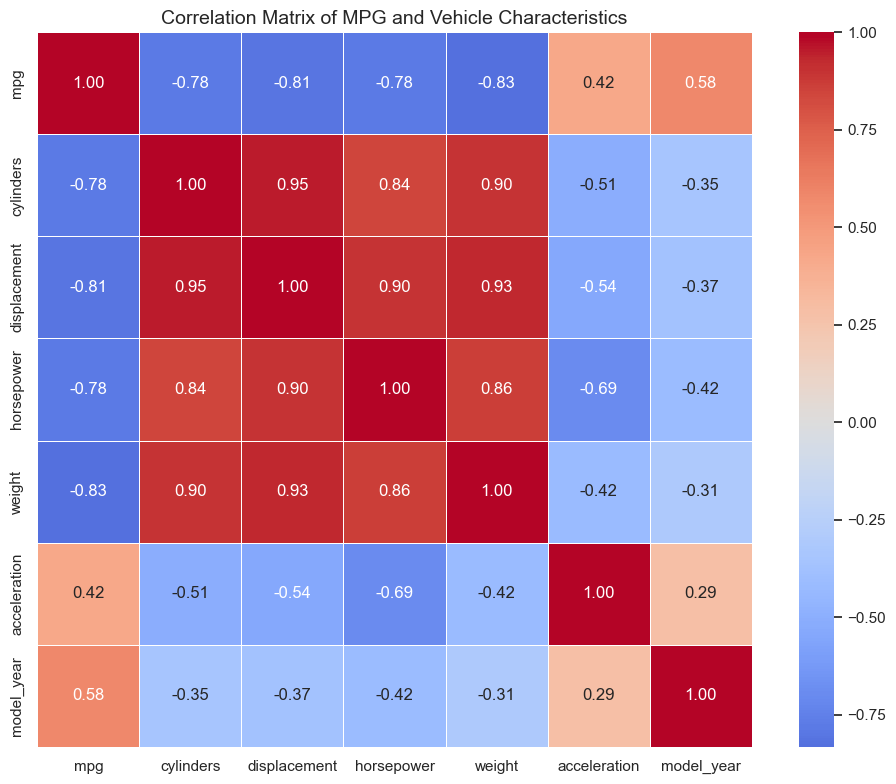

Correlation heatmap saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs\03_correlation_heatmap.png


In [13]:
# Select the target and predictor variables for correlation analysis
correlation_variables = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]

# Calculate the correlation matrix
correlation_matrix = (
    auto_mpg_clean_df[correlation_variables]
    .corr()
    .round(3)
)

print("Correlation Matrix:")
display(correlation_matrix)

# Create the correlation heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Matrix of MPG and Vehicle Characteristics",
    fontsize=14
)
plt.tight_layout()

# Save the heatmap
correlation_heatmap_path = (
    outputs_directory / "03_correlation_heatmap.png"
)

plt.savefig(
    correlation_heatmap_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Correlation heatmap saved to: {correlation_heatmap_path}")

## Step 17: AI-Assisted Visualization Recommendations

### Prompt Submitted to ChatGPT

> Recommend appropriate visualizations for a multiple linear regression analysis using `mpg` as the target variable and cylinders, displacement, horsepower, weight, acceleration, and model year as predictors. The visualizations should help examine relationships, interpret coefficients, and evaluate regression assumptions.

### AI Response and Recommendations

ChatGPT recommended the following visualizations:

1. **Correlation heatmap** to examine the strength and direction of relationships among variables.
2. **Scatterplot matrix or pairplot** to visualize relationships between `mpg` and each predictor.
3. **Coefficient plot** to compare the estimated effects of the predictors.
4. **Residual-versus-fitted plot** to evaluate linearity and constant error variance.
5. **Residual distribution or Q–Q plot** to assess whether regression residuals are approximately normally distributed.
6. **Actual-versus-predicted plot** to evaluate how closely the model predictions match observed MPG values.

These visualizations were selected because they support both exploratory analysis and evaluation of multiple linear regression assumptions.

## Step 18: Scatterplot Matrix

A scatterplot matrix is created to examine the relationships between vehicle fuel efficiency and the selected predictor variables. The visualization helps determine whether the relationships appear approximately linear and whether any clusters or unusual observations are present.

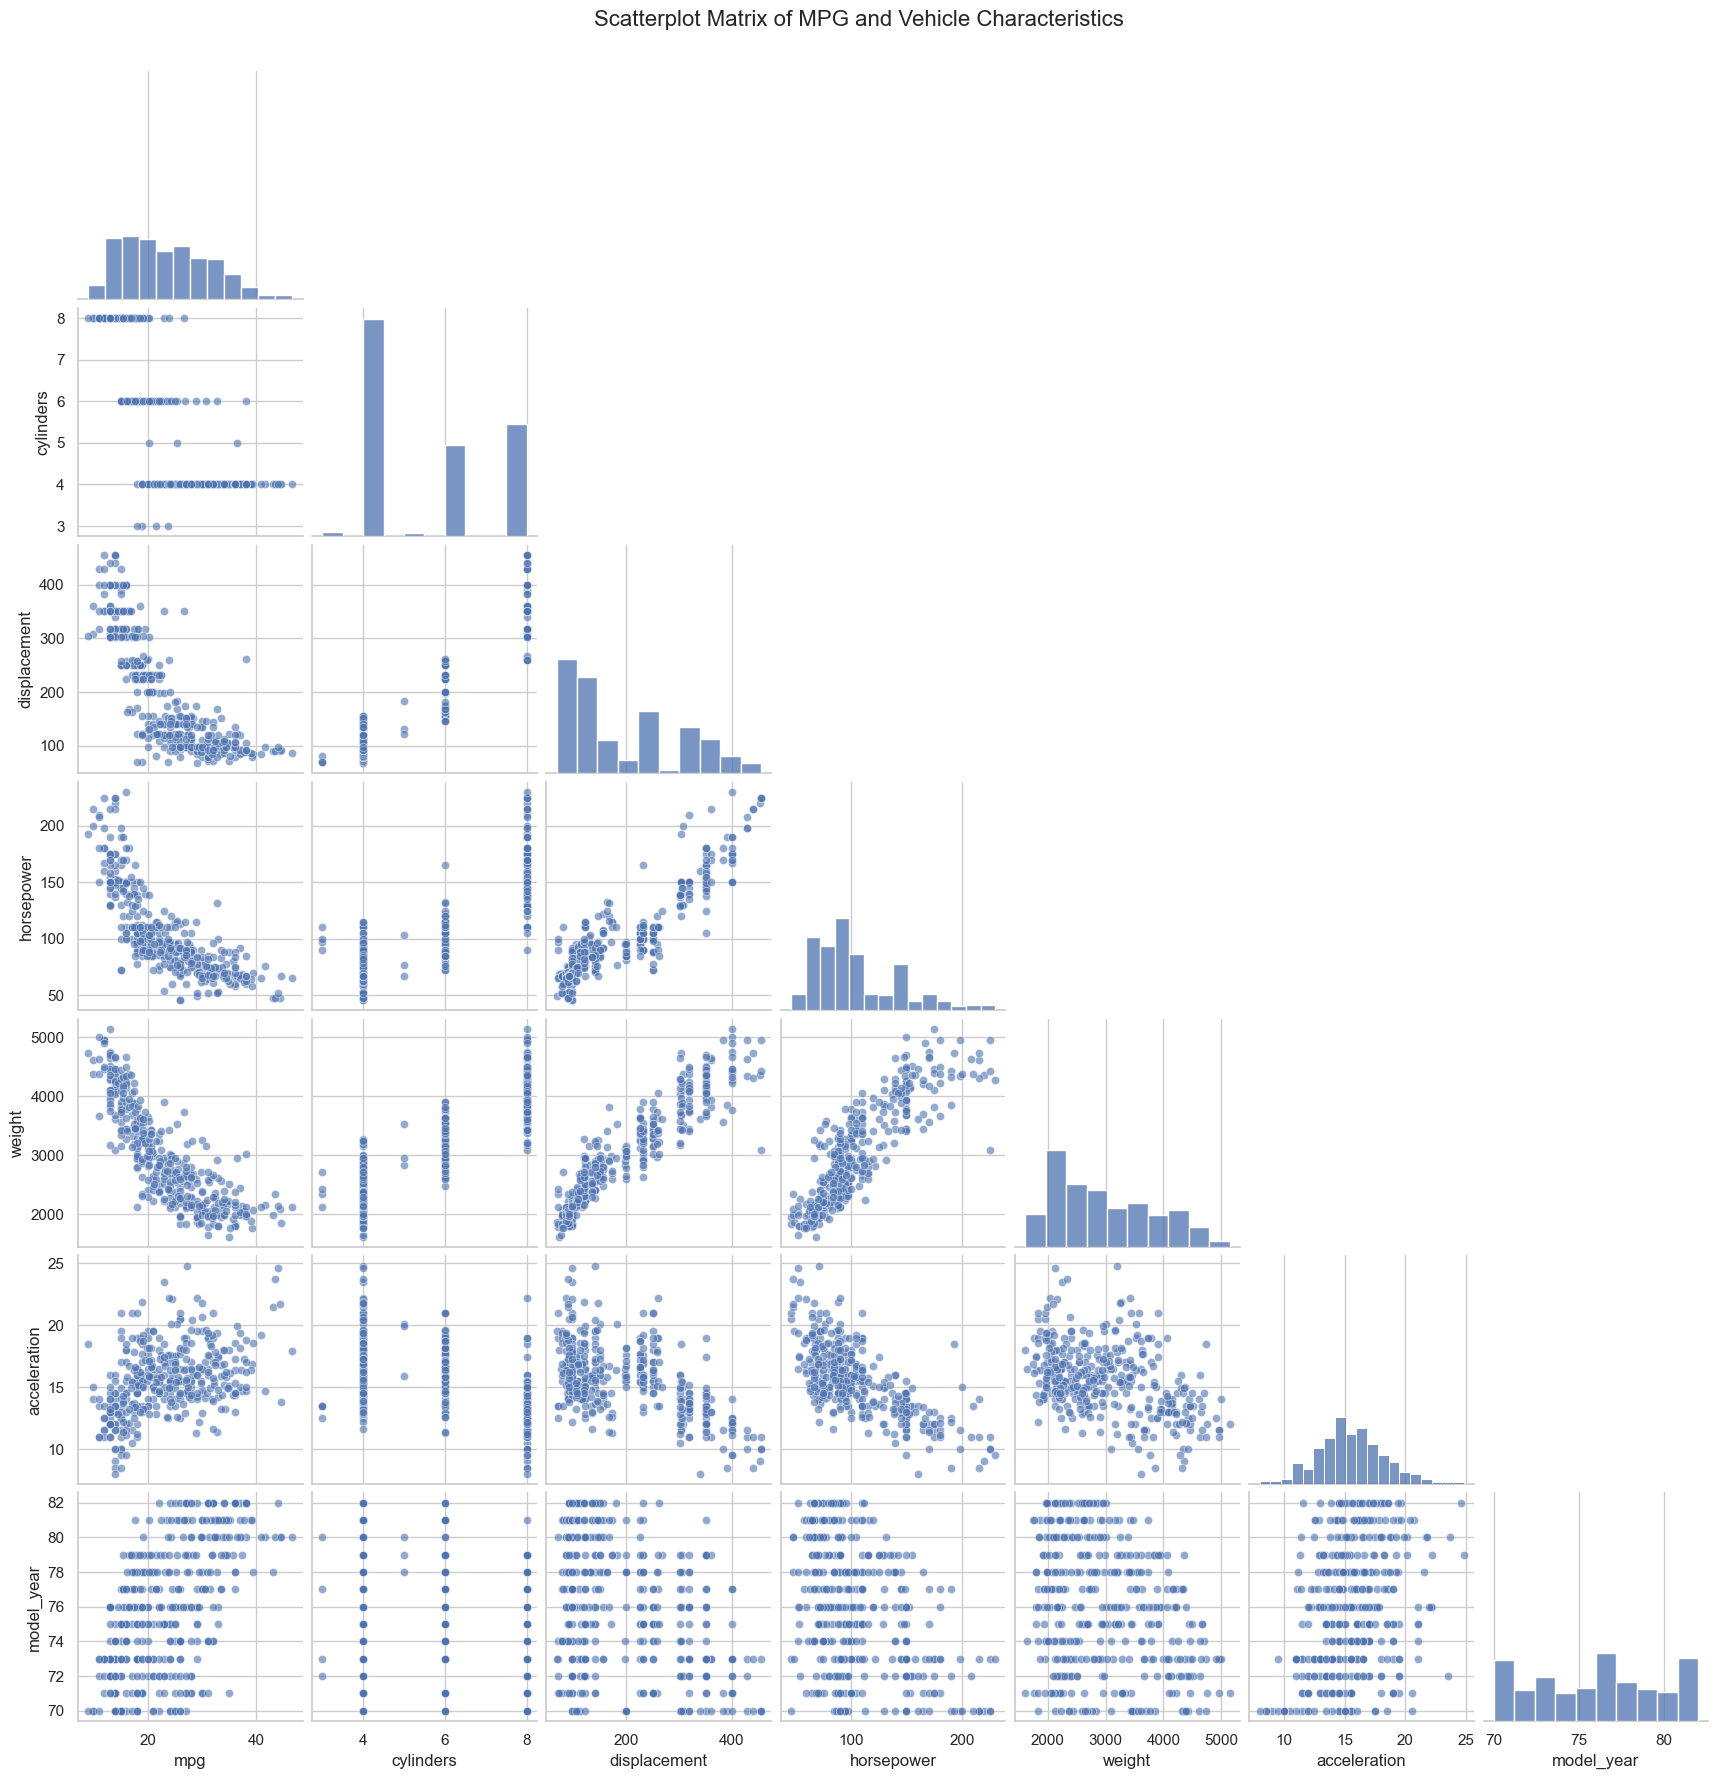

Scatterplot matrix saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs\04_scatterplot_matrix.png


In [14]:
# Select variables for the scatterplot matrix
pairplot_variables = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]

# Create the scatterplot matrix
pairplot_figure = sns.pairplot(
    auto_mpg_clean_df[pairplot_variables],
    corner=True,
    diag_kind="hist",
    plot_kws={
        "alpha": 0.6,
        "s": 35
    }
)

pairplot_figure.fig.suptitle(
    "Scatterplot Matrix of MPG and Vehicle Characteristics",
    y=1.02,
    fontsize=16
)

# Save the scatterplot matrix
pairplot_path = outputs_directory / "04_scatterplot_matrix.png"

pairplot_figure.savefig(
    pairplot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Scatterplot matrix saved to: {pairplot_path}")

## Step 19: Multiple Linear Regression Model and Hypotheses

A multiple linear regression model is used to examine how cylinders, displacement, horsepower, weight, acceleration, and model year collectively explain variation in vehicle fuel efficiency.

### Regression Equation

The general form of the model is:

\[
MPG = \beta_0 + \beta_1(Cylinders) + \beta_2(Displacement)
+ \beta_3(Horsepower) + \beta_4(Weight)
+ \beta_5(Acceleration) + \beta_6(ModelYear) + \epsilon
\]

### Overall Model Hypotheses

**Null hypothesis (\(H_0\)):**

\[
\beta_1 = \beta_2 = \beta_3 = \beta_4 = \beta_5 = \beta_6 = 0
\]

The selected vehicle characteristics do not collectively have a statistically significant linear relationship with MPG.

**Alternative hypothesis (\(H_a\)):**

At least one regression coefficient is not equal to zero.

At least one selected vehicle characteristic has a statistically significant linear relationship with MPG.

A significance level of \(\alpha = 0.05\) is used.

In [15]:
# Define the predictor variables and target variable
predictor_variables = [
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year"
]

X = auto_mpg_clean_df[predictor_variables]
y = auto_mpg_clean_df["mpg"]

# Add a constant term to estimate the regression intercept
X_with_constant = sm.add_constant(X)

# Build the Ordinary Least Squares multiple regression model
regression_model = sm.OLS(y, X_with_constant).fit()

# Display the complete regression results
print(regression_model.summary())

# Save the regression summary as a text file
regression_summary_path = outputs_directory / "05_regression_summary.txt"

with open(regression_summary_path, "w", encoding="utf-8") as summary_file:
    summary_file.write(regression_model.summary().as_text())

print(f"\nRegression summary saved to: {regression_summary_path}")

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     272.2
Date:                Wed, 24 Jun 2026   Prob (F-statistic):          3.79e-135
Time:                        22:17:20   Log-Likelihood:                -1036.5
No. Observations:                 392   AIC:                             2087.
Df Residuals:                     385   BIC:                             2115.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -14.5353      4.764     -3.051   

## Step 20: Model Performance and Coefficient Results

The model's R² and adjusted R² values measure how much variation in MPG is explained by the predictors. The F-test evaluates whether the overall regression model is statistically significant. Individual p-values test whether each predictor contributes significantly after controlling for the other variables.

In [16]:
# Extract the confidence intervals
confidence_intervals = regression_model.conf_int()

# Create a table containing coefficient results
coefficient_results_df = pd.DataFrame({
    "Coefficient": regression_model.params,
    "Standard_Error": regression_model.bse,
    "t_Value": regression_model.tvalues,
    "p_Value": regression_model.pvalues,
    "CI_Lower_95": confidence_intervals[0],
    "CI_Upper_95": confidence_intervals[1]
})

coefficient_results_df.index.name = "Variable"

# Display the primary model metrics
print("Multiple Linear Regression Model Metrics")
print("-" * 50)
print(f"R-squared: {regression_model.rsquared:.4f}")
print(f"Adjusted R-squared: {regression_model.rsquared_adj:.4f}")
print(f"F-statistic: {regression_model.fvalue:.4f}")
print(f"F-test p-value: {regression_model.f_pvalue:.6f}")
print(f"Number of observations: {int(regression_model.nobs)}")

print("\nRegression Coefficient Results:")
display(coefficient_results_df.round(4))

# Save the coefficient results
coefficient_results_path = (
    outputs_directory / "06_regression_coefficient_results.csv"
)

coefficient_results_df.to_csv(coefficient_results_path)

print(f"Coefficient results saved to: {coefficient_results_path}")

Multiple Linear Regression Model Metrics
--------------------------------------------------
R-squared: 0.8093
Adjusted R-squared: 0.8063
F-statistic: 272.2341
F-test p-value: 0.000000
Number of observations: 392

Regression Coefficient Results:


,Coefficient,Standard_Error,t_Value,p_Value,CI_Lower_95,CI_Upper_95
Variable,,,,,,
const,-14.5353,4.7639,-3.0511,0.0024,-23.9017,-5.1688
cylinders,-0.3299,0.3321,-0.9932,0.3212,-0.9828,0.3231
displacement,0.0077,0.0074,1.0436,0.2973,-0.0068,0.0221
horsepower,-0.0004,0.0138,-0.0283,0.9775,-0.0276,0.0268
weight,-0.0068,0.0007,-10.1409,0.0000,-0.0081,-0.0055
acceleration,0.0853,0.1020,0.8357,0.4038,-0.1153,0.2859
model_year,0.7534,0.0526,14.3176,0.0000,0.6499,0.8568


Coefficient results saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs\06_regression_coefficient_results.csv


## Step 21: Multicollinearity Evaluation

Variance inflation factors are calculated to evaluate whether the predictor variables are highly correlated with one another. High multicollinearity can make individual regression coefficients unstable and difficult to interpret.

In [17]:
# Import the VIF calculation function
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF using the predictor matrix with the constant
vif_results = []

for column_index, column_name in enumerate(X_with_constant.columns):
    vif_value = variance_inflation_factor(
        X_with_constant.values,
        column_index
    )

    vif_results.append({
        "Variable": column_name,
        "VIF": vif_value
    })

vif_results_df = pd.DataFrame(vif_results)

# Exclude the constant because its VIF is not interpreted
vif_predictors_df = vif_results_df[
    vif_results_df["Variable"] != "const"
].reset_index(drop=True)

print("Variance Inflation Factor Results:")
display(vif_predictors_df.round(3))

# Save the VIF results
vif_results_path = outputs_directory / "07_vif_results.csv"
vif_predictors_df.to_csv(vif_results_path, index=False)

print(f"VIF results saved to: {vif_results_path}")

Variance Inflation Factor Results:


,Variable,VIF
0,cylinders,10.633
1,displacement,19.642
2,horsepower,9.398
3,weight,10.732
4,acceleration,2.626
5,model_year,1.245


VIF results saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs\07_vif_results.csv


## Step 22: Standardized Coefficient Plot

A standardized regression model is fitted so that predictor effects can be compared on the same measurement scale. The coefficient plot includes 95% confidence intervals and shows the direction and relative strength of each predictor's relationship with MPG.

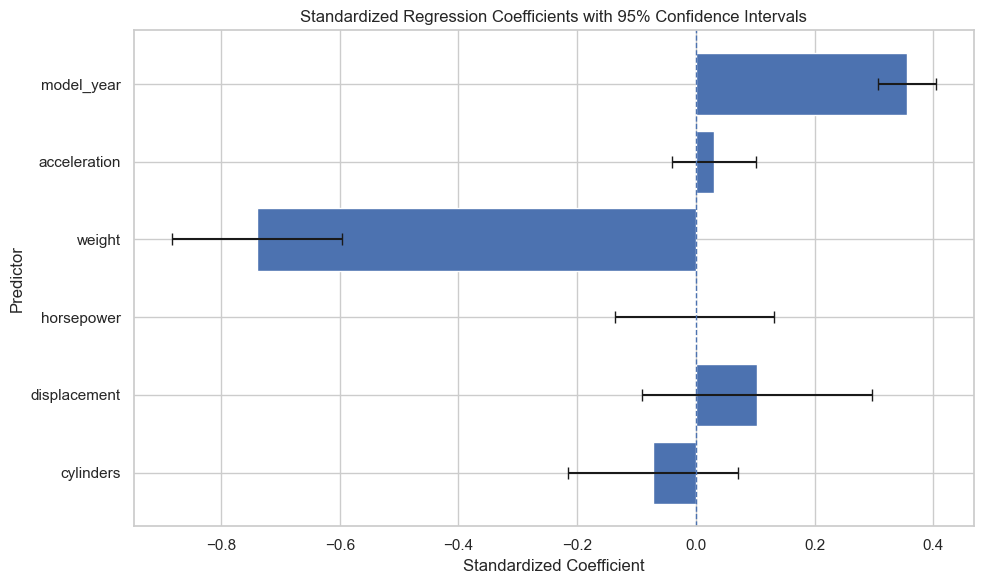

Coefficient plot saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs\08_standardized_coefficient_plot.png


In [18]:
# Standardize the target and predictor variables
standardized_data = auto_mpg_clean_df[
    ["mpg"] + predictor_variables
].apply(
    lambda column: (
        column - column.mean()
    ) / column.std()
)

X_standardized = sm.add_constant(
    standardized_data[predictor_variables]
)

y_standardized = standardized_data["mpg"]

# Build the standardized regression model
standardized_model = sm.OLS(
    y_standardized,
    X_standardized
).fit()

# Extract standardized coefficients and confidence intervals
standardized_coefficients = (
    standardized_model.params.drop("const")
)

standardized_confidence_intervals = (
    standardized_model.conf_int().drop("const")
)

# Calculate confidence interval distances
lower_errors = (
    standardized_coefficients
    - standardized_confidence_intervals[0]
)

upper_errors = (
    standardized_confidence_intervals[1]
    - standardized_coefficients
)

coefficient_errors = np.vstack([
    lower_errors,
    upper_errors
])

# Create the coefficient plot
plt.figure(figsize=(10, 6))

plt.barh(
    standardized_coefficients.index,
    standardized_coefficients.values,
    xerr=coefficient_errors,
    capsize=4
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Standardized Regression Coefficients with 95% Confidence Intervals"
)

plt.xlabel("Standardized Coefficient")
plt.ylabel("Predictor")
plt.tight_layout()

# Save the figure
coefficient_plot_path = (
    outputs_directory / "08_standardized_coefficient_plot.png"
)

plt.savefig(
    coefficient_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Coefficient plot saved to: {coefficient_plot_path}")

## Step 23: Regression Diagnostic Visualizations

Residual and prediction plots are used to evaluate the performance and assumptions of the multiple linear regression model. These visualizations examine linearity, constant error variance, residual normality, and agreement between observed and predicted MPG values.

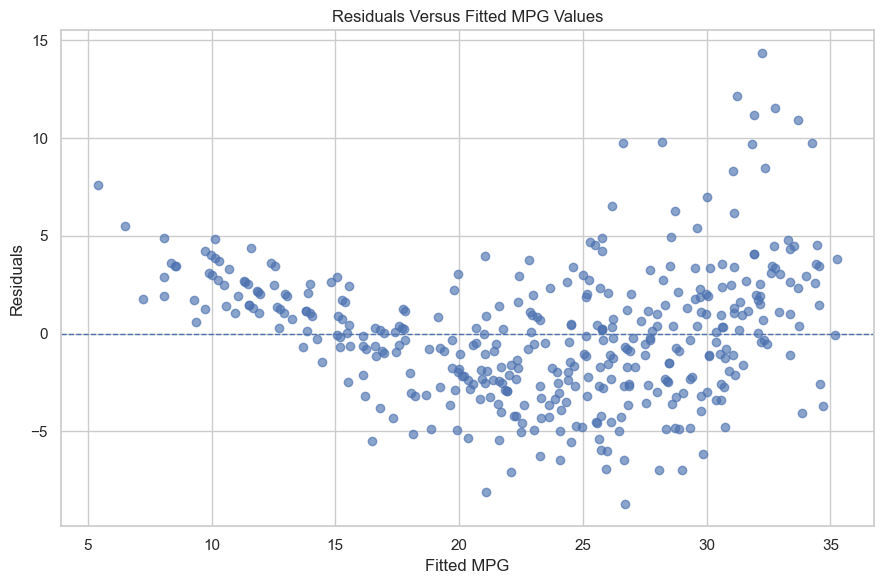

Residual plot saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs\09_residuals_vs_fitted.png


In [19]:
# Obtain fitted values and residuals
fitted_values = regression_model.fittedvalues
residuals = regression_model.resid

# Create the residual-versus-fitted plot
plt.figure(figsize=(9, 6))

plt.scatter(
    fitted_values,
    residuals,
    alpha=0.65
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.title("Residuals Versus Fitted MPG Values")
plt.xlabel("Fitted MPG")
plt.ylabel("Residuals")
plt.tight_layout()

residual_plot_path = (
    outputs_directory / "09_residuals_vs_fitted.png"
)

plt.savefig(
    residual_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Residual plot saved to: {residual_plot_path}")

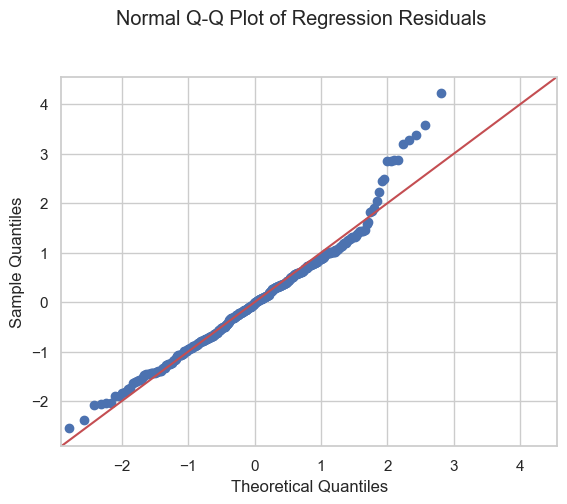

Q-Q plot saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs\10_residual_qq_plot.png


In [20]:
# Create a Q-Q plot to evaluate residual normality
qq_figure = sm.qqplot(
    residuals,
    line="45",
    fit=True
)

qq_figure.suptitle(
    "Normal Q-Q Plot of Regression Residuals",
    y=1.02
)

qq_plot_path = outputs_directory / "10_residual_qq_plot.png"

qq_figure.savefig(
    qq_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Q-Q plot saved to: {qq_plot_path}")

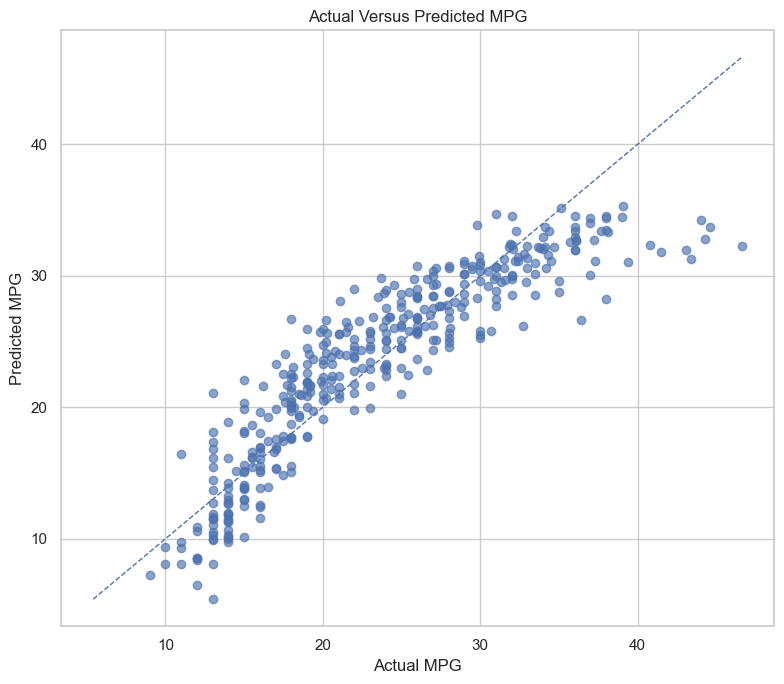

Actual-versus-predicted plot saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs\11_actual_vs_predicted_mpg.png


In [21]:
# Determine the plotting range
minimum_mpg = min(y.min(), fitted_values.min())
maximum_mpg = max(y.max(), fitted_values.max())

# Create the actual-versus-predicted plot
plt.figure(figsize=(8, 7))

plt.scatter(
    y,
    fitted_values,
    alpha=0.65
)

# Add a perfect-prediction reference line
plt.plot(
    [minimum_mpg, maximum_mpg],
    [minimum_mpg, maximum_mpg],
    linestyle="--",
    linewidth=1
)

plt.title("Actual Versus Predicted MPG")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.tight_layout()

actual_predicted_path = (
    outputs_directory / "11_actual_vs_predicted_mpg.png"
)

plt.savefig(
    actual_predicted_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Actual-versus-predicted plot saved to: "
    f"{actual_predicted_path}"
)

## Step 24: Statistical Diagnostic Tests

Formal diagnostic tests are conducted to supplement the residual visualizations. The Breusch–Pagan test examines constant error variance, the Jarque–Bera test examines residual normality, and the Durbin–Watson statistic evaluates residual independence.

In [22]:
# Import regression diagnostic tests
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera, durbin_watson

# Breusch-Pagan test for heteroscedasticity
bp_test = het_breuschpagan(
    residuals,
    regression_model.model.exog
)

bp_labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

bp_results = dict(zip(bp_labels, bp_test))

# Jarque-Bera test for residual normality
jb_statistic, jb_p_value, residual_skew, residual_kurtosis = (
    jarque_bera(residuals)
)

# Durbin-Watson test for residual independence
durbin_watson_value = durbin_watson(residuals)

print("Breusch-Pagan Test")
print("-" * 40)

for label, value in bp_results.items():
    print(f"{label}: {value:.6f}")

print("\nJarque-Bera Test")
print("-" * 40)
print(f"JB Statistic: {jb_statistic:.6f}")
print(f"JB p-value: {jb_p_value:.6f}")
print(f"Residual skewness: {residual_skew:.4f}")
print(f"Residual kurtosis: {residual_kurtosis:.4f}")

print("\nDurbin-Watson Statistic")
print("-" * 40)
print(f"Durbin-Watson: {durbin_watson_value:.4f}")

Breusch-Pagan Test
----------------------------------------
LM Statistic: 29.944165
LM p-value: 0.000040
F Statistic: 5.306964
F p-value: 0.000028

Jarque-Bera Test
----------------------------------------
JB Statistic: 60.248498
JB p-value: 0.000000
Residual skewness: 0.6301
Residual kurtosis: 4.4493

Durbin-Watson Statistic
----------------------------------------
Durbin-Watson: 1.2319


In [23]:
# Create a summary table of the primary model metrics
model_metrics_df = pd.DataFrame({
    "Metric": [
        "Number of Observations",
        "R-squared",
        "Adjusted R-squared",
        "F-statistic",
        "F-test p-value",
        "Durbin-Watson Statistic",
        "Breusch-Pagan p-value",
        "Jarque-Bera p-value"
    ],
    "Value": [
        int(regression_model.nobs),
        regression_model.rsquared,
        regression_model.rsquared_adj,
        regression_model.fvalue,
        regression_model.f_pvalue,
        durbin_watson_value,
        bp_results["LM p-value"],
        jb_p_value
    ]
})

# Create a dataset containing observed values, predictions, and residuals
prediction_results_df = pd.DataFrame({
    "Actual_MPG": y,
    "Predicted_MPG": fitted_values,
    "Residual": residuals
})

# Save both result tables
model_metrics_path = outputs_directory / "12_model_metrics.csv"
prediction_results_path = outputs_directory / "13_prediction_results.csv"

model_metrics_df.to_csv(model_metrics_path, index=False)
prediction_results_df.to_csv(prediction_results_path, index=False)

print("Final Model Metrics:")
display(model_metrics_df)

print(f"\nModel metrics saved to: {model_metrics_path}")
print(f"Prediction results saved to: {prediction_results_path}")

Final Model Metrics:


,Metric,Value
0,Number of Observations,3.920000e+02
1,R-squared,8.092553e-01
2,Adjusted R-squared,8.062826e-01
3,F-statistic,2.722341e+02
4,F-test p-value,3.792336e-135
5,Durbin-Watson Statistic,1.231883e+00
6,Breusch-Pagan p-value,4.028092e-05
7,Jarque-Bera p-value,8.264277e-14



Model metrics saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs\12_model_metrics.csv
Prediction results saved to: c:\Users\dubey\Documents\UC_GitLab\Summer_2026_BI_Sem_1\Data_Science_and_Big_Data_Analytics\Lab_13_Exploring_Data_Insights\outputs\13_prediction_results.csv


In [24]:
# Display all files currently saved in the outputs folder
print("Files Saved in the Outputs Folder:")
print("-" * 60)

for output_file in sorted(outputs_directory.iterdir()):
    if output_file.is_file():
        print(output_file.name)

Files Saved in the Outputs Folder:
------------------------------------------------------------
01_auto_mpg_first_10_rows.png
02_model_variables_boxplots.png
03_correlation_heatmap.png
04_scatterplot_matrix.png
05_regression_summary.txt
06_regression_coefficient_results.csv
07_vif_results.csv
08_standardized_coefficient_plot.png
09_residuals_vs_fitted.png
10_residual_qq_plot.png
11_actual_vs_predicted_mpg.png
12_model_metrics.csv
13_prediction_results.csv
